In [1]:
from pathlib import Path
import numpy as np

def load_scanned_object(name):
    E_shift = 2
    if name == "matka_boska":
        e_xy = np.load(Path("data/objects/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)
        peaks = [720, 985, 1594, 2068]
        peak_energies = [3.692, 5.088, 8.046, 10.551]    
    elif name == "sobieski":
        e_xy = np.load(Path("data/objects/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)
        peaks=[817, 1016,1347, 1598]
        peak_energies=[6.405, 8.046, 10.551, 12.614] 
    elif name == "gasecki":
        e_xy = np.load(Path("data/objects/Gasecki/Gasecki_data_corr_total.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)
        peaks=[1360, 1623]
        peak_energies=[10.551, 12.614]  
    elif name == "cu":
        e_xy = np.load(Path("data/objects/Blank_PcbCu/GEM_Cr_PBS1_Blank_PcbCu_ArCO2_75_25_Gain_35_Thr_35_HV_3640_Xray_50kV_04mA_part_001_GainCorr.pcap.dat.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)
        peaks = [1000, 1614]
        peak_energies = [5.088, 8.046]
    else:
        raise ValueError(f"Unknown object name: {name}")

    return e_xy, peaks, peak_energies


def average_patches(e_xy, patch_size = 1):
    if patch_size == 1:
        return e_xy
    A = patch_size
    X, Y, C = e_xy.shape

    X_trim = X - (X % A)
    Y_trim = Y - (Y % A)
    e_xy = e_xy[:X_trim, :Y_trim, :]

    X_prime = X_trim // A
    Y_prime = Y_trim // A
    e_xy_patched = e_xy.reshape(X_prime, A, Y_prime, A, C)
    averaged = e_xy_patched.mean(axis=(1, 3))

    return averaged  # shape will be (X//A, Y//A, C)

In [2]:
object_name = "matka_boska"
# object_name = "sobieski"
patch_size = 1 

e_xy, peaks, peak_energies = load_scanned_object(object_name)
# e_xy = average_patches(e_xy, patch_size)

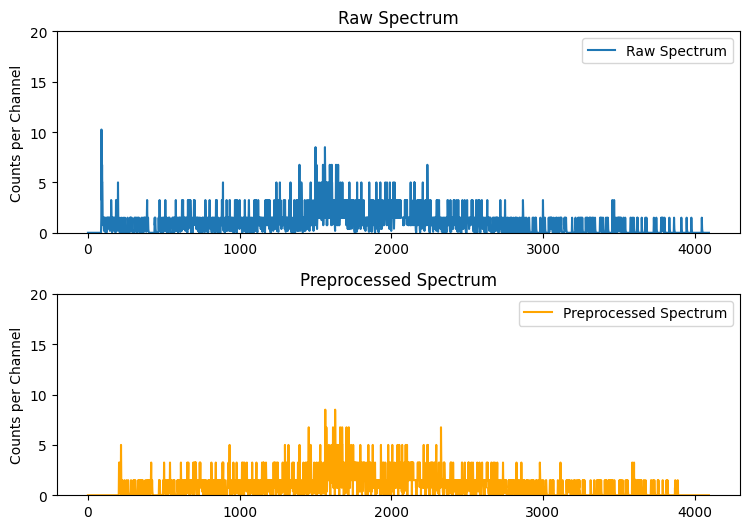

In [3]:
import matplotlib.pyplot as plt
from src.DataPreprocessor import DataPreprocessor

fig, axs = plt.subplots(2, 1, figsize=(8, 6))  # Add this if not already present
e_xy[50, 50] = e_xy[50, 50] 

# Raw spectrum
axs[0].plot(e_xy[50, 50], label="Raw Spectrum")
axs[0].legend()
axs[0].set_ylim(0, 20)
axs[0].set_title("Raw Spectrum")
axs[0].set_ylabel("Counts per Channel")

# Processed spectrum
tmp = DataPreprocessor.processed_spectrum(
    e_xy[50, 50], peaks, peak_energies, discrete_transformation=True
)[1]
axs[1].plot(np.arange(0, 4096), tmp, label="Preprocessed Spectrum", color='orange')
axs[1].legend()
axs[1].set_ylim(0, 20)
axs[1].set_title("Preprocessed Spectrum")
axs[1].set_ylabel("Counts per Channel")

# Global labels and title

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])  # Adjust layout to fit global labels
plt.savefig(f"data/plots/{object_name}_spectrum_discrete.svg", bbox_inches='tight', pad_inches=0)


In [4]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

def apply_smoothing_and_padding(e_xy, padding_size=196, spatial_smoothing=False, channel_smoothing=False):
    result = e_xy
    if spatial_smoothing:
        result = gaussian(result, sigma=0.6)
    if channel_smoothing: 
        result = np.apply_along_axis(
            gaussian, axis=2, arr=result, sigma=64, preserve_range=True
        )
    
    result[:, :, :padding_size] = 0
    result[:, :, -padding_size:] = 0
    
    # max_norm_coeff = np.max(result, axis=2, keepdims=True)
    # result /= max_norm_coeff

    return result 

e_xy_smooth = apply_smoothing_and_padding(e_xy, spatial_smoothing=True, channel_smoothing=True)

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:157: RuntimeWarning: Pixel-wise extrapolation may be slow.
  warnings.warn("Pixel-wise extrapolation may be slow.", RuntimeWarning)


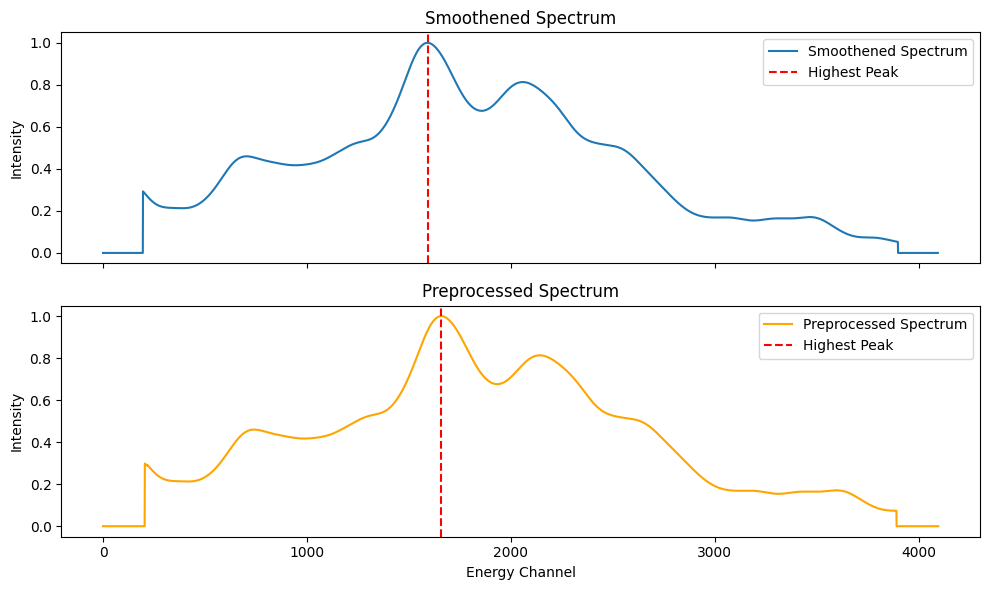

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Raw spectrum
axs[0].plot(e_xy_smooth[50, 50] / np.max(e_xy_smooth[50, 50]), label=f"Smoothened Spectrum")
axs[0].axvline(x=np.argmax(e_xy_smooth[50, 50]), color='red', linestyle='--', label='Highest Peak')
axs[0].set_title("Smoothened Spectrum")
axs[0].legend()
axs[0].set_ylabel("Intensity")

# Processed spectrum
tmp = DataPreprocessor.processed_spectrum(
    e_xy_smooth[50, 50], peaks, peak_energies
)[1]
axs[1].plot(np.arange(0, 4096), tmp, label=f"Preprocessed Spectrum", color='orange')
axs[1].axvline(x=np.argmax(tmp), color='red', linestyle='--', label='Highest Peak')
axs[1].set_title("Preprocessed Spectrum")
axs[1].legend()

plt.xlabel("Energy Channel")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.savefig(f"data/plots/{object_name}_spectrum_smooth.svg", bbox_inches='tight', pad_inches=0)

(108, 0)
(2, 200)
(71, 47)
(254, 109)
(141, 125)


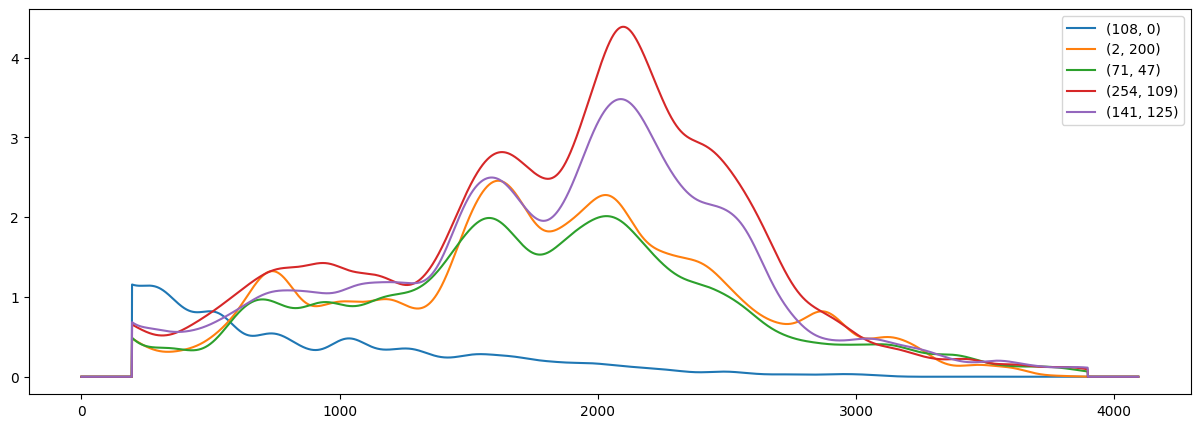

In [6]:
import matplotlib.pyplot as plt
import random 
plt.figure(figsize=(15, 5))
for i in range(5):
    xy = random.randint(0, e_xy_smooth.shape[0]-1), random.randint(0, e_xy_smooth.shape[1]-1)
    print(xy)
    plt.plot(e_xy_smooth[xy], label=str(xy))
plt.legend()

In [7]:
energy_range, e_xy_processed = DataPreprocessor.processed_spectra(e_xy_smooth, peaks, peak_energies, discrete_transformation=True)
H, W, C = e_xy_processed.shape

(51, 24)
(268, 58)
(119, 112)
(204, 60)
(188, 100)


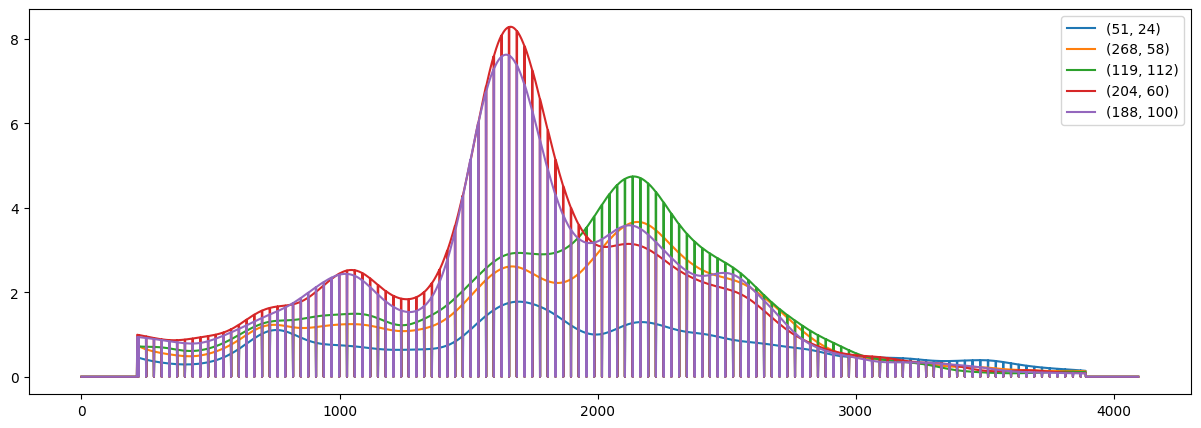

In [8]:
plt.figure(figsize=(15, 5))
for i in range(5):
    xy = random.randint(0, e_xy_processed.shape[0]-1), random.randint(0, e_xy_smooth.shape[1]-1)
    print(xy)
    plt.plot(e_xy_processed[xy], label=str(xy))
plt.legend()

In [9]:
import matplotlib.pyplot as plt

def plot_pad_max_peak_positions(e_xy, object_name):
    peak_map = np.argmax(e_xy, axis=2)

    _, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(peak_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Max peak position")
    plt.title("Max Peak Positions")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    
    plt.savefig(f"data/plots/max_peak_positions{object_name}.svg", bbox_inches='tight',  pad_inches=0)

def plot_pad_photon_counts(e_xy, object_name): 
    photon_count_map = np.sum(e_xy, axis=2)
    photon_count_map /= np.max(photon_count_map)

    _, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    im = ax.imshow(photon_count_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    plt.savefig(f"data/plots/photon_counts{object_name}.svg", bbox_inches='tight',  pad_inches=0)

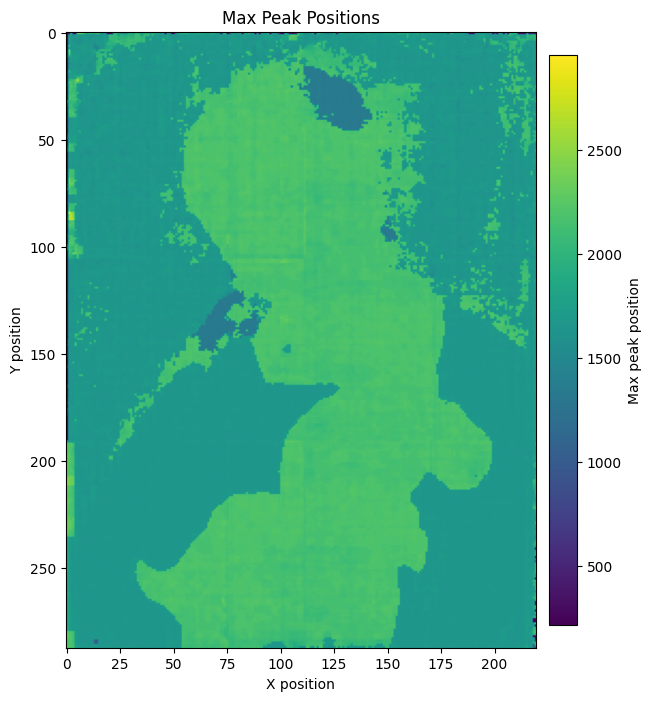

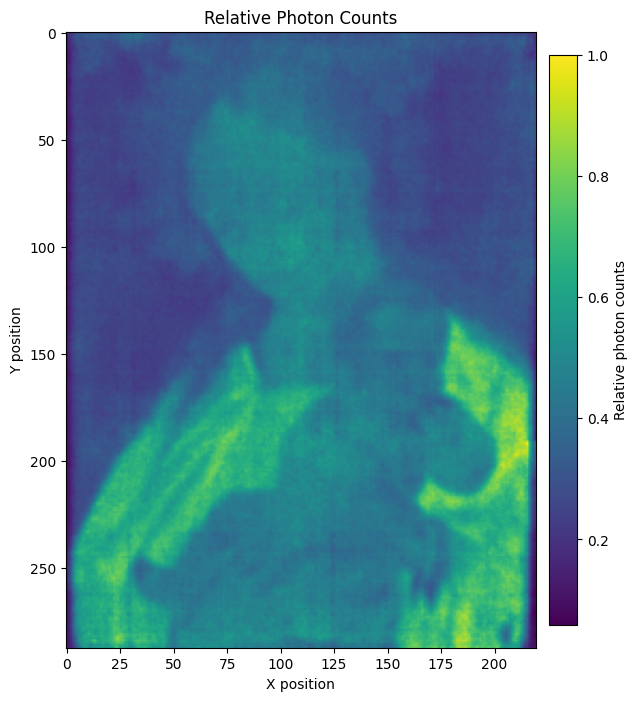

In [10]:
plot_pad_max_peak_positions(e_xy_processed, object_name)
plot_pad_photon_counts(e_xy_processed, object_name)

In [ ]:
result = {"e_xy": e_xy_processed, "peaks": peaks, "peak_energies": peak_energies }
np.savez(
    f"data/objects/processed/{object_name}_{patch_size}x{patch_size}_patches_discrete.npz", **result
)

: 